# Lecture 04 — Vehicle usage clustering

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Clustering (K-means) · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Explore grouping patterns in mileage, fuel consumption and vehicle age.

## Practical problem
A fleet operator wants to summarise broad patterns of vehicle use without assigning prior labels.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** The values represent fabricated fleet profiles and are not real maintenance statistics.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 540 rows × 4 columns


,annual_km,fuel_l_per_100km,vehicle_age_years,synthetic_group
0,17761.0,8.7,3.2,1
1,40229.0,11.1,14.5,2
2,41343.0,13.0,9.9,2
3,26736.0,6.7,6.5,1
4,3671.0,5.7,3.0,0


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['annual_km', 'fuel_l_per_100km', 'vehicle_age_years', 'synthetic_group']
Missing values per column:
annual_km            0
fuel_l_per_100km     0
vehicle_age_years    0
synthetic_group      0


## 2. Explore the unlabeled structure
Clustering has **no class target** supplied to training. The extra `synthetic_group` column is held out and used only to evaluate how well the model rediscovered the known simulated groups.

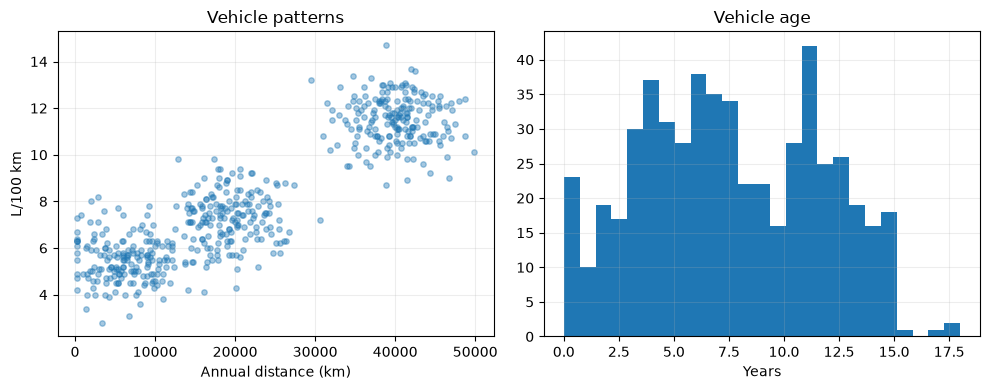

In [3]:
fig,ax=plt.subplots(1,2,figsize=(10,4))
ax[0].scatter(df['annual_km'],df['fuel_l_per_100km'],s=15,alpha=.4)
ax[0].set(xlabel='Annual distance (km)',ylabel='L/100 km',title='Vehicle patterns')
ax[1].hist(df['vehicle_age_years'],bins=25);ax[1].set(title='Vehicle age',xlabel='Years');plt.tight_layout();plt.show()

## 3. Scale features and perform K-means
K-means repeatedly assigns observations to the nearest centroid and updates centroids. Standard scaling prevents one feature measured in large numerical units from dominating Euclidean distance.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,adjusted_rand_score
features=['annual_km', 'fuel_l_per_100km', 'vehicle_age_years']
scaler=StandardScaler()
X=scaler.fit_transform(df[features])
model=KMeans(n_clusters=3,random_state=42,n_init=10)
clusters=model.fit_predict(X)
df['cluster']=clusters
print('Cluster sizes:',pd.Series(clusters).value_counts().sort_index().to_dict())
print('Silhouette score:',round(silhouette_score(X,clusters),3))
print('Adjusted Rand Index versus simulated groups:',round(adjusted_rand_score(df['synthetic_group'],clusters),3))
print('Centroids in original units:')
display(pd.DataFrame(scaler.inverse_transform(model.cluster_centers_),columns=features).round(2))

Cluster sizes: {0: 192, 1: 170, 2: 178}
Silhouette score: 0.543
Adjusted Rand Index versus simulated groups: 0.953
Centroids in original units:


,annual_km,fuel_l_per_100km,vehicle_age_years
0,40067.40,11.50,11.92
1,6515.29,5.41,3.14
2,18833.90,7.32,7.12


## 4. Draw the clusters
Points are coloured by their **discovered cluster**. Cluster numbers have no intrinsic meaning (Cluster 0 is not automatically “best”).

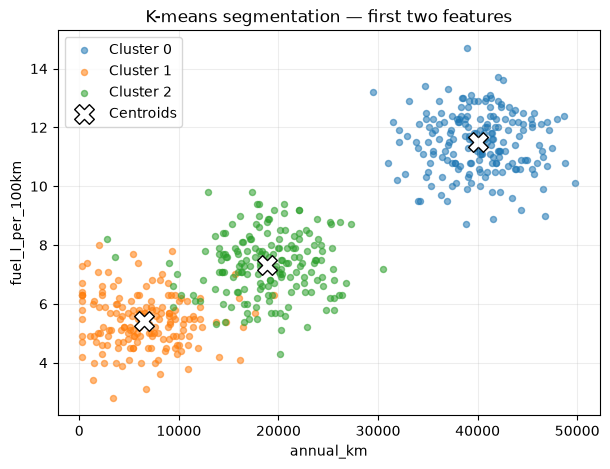

In [5]:
fig,ax=plt.subplots(figsize=(7,5))
for k in range(3):
 mask=df['cluster']==k
 ax.scatter(df.loc[mask,features[0]],df.loc[mask,features[1]],alpha=.55,s=19,label=f'Cluster {k}')
centres=scaler.inverse_transform(model.cluster_centers_)
ax.scatter(centres[:,0],centres[:,1],marker='X',s=200,edgecolor='black',color='white',label='Centroids')
ax.set(xlabel=features[0],ylabel=features[1],title='K-means segmentation — first two features');ax.legend();plt.show()

## 5. Assign a new observation to a cluster
Transform the new values with the **same fitted scaler** before calling K-means `predict`. Describe its group using the centroid table, not its arbitrary numeric ID.

In [6]:
vehicles=pd.DataFrame([{'annual_km':8000,'fuel_l_per_100km':5.2,'vehicle_age_years':2},{'annual_km':42000,'fuel_l_per_100km':11.0,'vehicle_age_years':14}])
vehicles['cluster']=model.predict(scaler.transform(vehicles[features]));display(vehicles)

,annual_km,fuel_l_per_100km,vehicle_age_years,cluster
0,8000,5.2,2,1
1,42000,11.0,14,0


## 6. What do clustering metrics mean?
**Silhouette** compares within-cluster cohesion with separation; higher (toward 1) generally indicates more compact, separated clusters. **Adjusted Rand Index** compares assignments with `synthetic_group`, which is only available because we designed the simulation. Do not report accuracy, precision, recall or confusion matrix as though arbitrary cluster IDs were supervised labels.

## Student investigation and discussion
1. Should clusters be used to schedule maintenance without further validation?
2. How could using raw annual_km dominate grouping?
3. What domain information helps interpret clusters?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.